# SAM3 Tutorial & Text Prompt Sandbox
This notebook provides the necessary environment setup instructions, an installation tutorial, and basic SAM3 API call examples to guide your understanding.

## 1. Setup & Installation
Run the cell below to install the necessary dependencies for running SAM3 locally or on Colab.

In [ ]:
!pip install -q transformers torchvision opencv-python matplotlib huggingface_hub

### Step-by-Step Guide for SAM3 Token Access

SAM 3 is a **gated model** on Hugging Face.

**Step 1 - Create a free Hugging Face account (if you don't have one):**  
https://huggingface.co/join

**Step 2 - Request access to the SAM 3 checkpoint:**  
https://huggingface.co/facebook/sam3  
Click **"Access repository"**, fill in the short form using your RPI email, and submit. Access is usually granted in a few minutes to 30 minutes. You
should request access early rather than waiting until they are ready to run the
notebook.

**Step 3 - Create an access token** \
**Get your access token here:** https://huggingface.co/settings/tokens  
Create a token with **read** permissions.

- **Security note:** Never paste your token into a shared notebook or commit it to Git. Use the interactive prompt below.

**Step 4 - Authenticate** \
After obtaining the token, authentication can be performed directly in Python
using the Hugging Face Hub library:
```python
from huggingface_hub import login
login("hf_your_token_here")
```
Alternatively, authentication can be done through the command line interface:
```python
!hf auth login
```
In that case, the user will be prompted to paste the token interactively.

#### Common Failure Cases
If loading the model still fails after authentication, the following points should
be checked:
- the access request forfacebook/sam3has actually been approved,
- the token belongs to the same Hugging Face account that received approval,
- the token has at leastreadpermission,
- authentication was completed before callingfrom pretrained(...).
These are the most common causes of access failure when working with gated
models.

In [ ]:
from huggingface_hub import login

# Paste your actual Hugging Face token below:
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


## 2. Load SAM3 Model (Hardware Check)
SAM3 requires significant computational power. The code below detects your underlying compute device (CUDA / MPS / CPU) and loads the model API into memory.

The first time you run this cell the checkpoint (**~3 GB**) will be downloaded and cached. Subsequent runs in the same session load from the local cache and are much faster.

In [ ]:
import torch
from transformers import Sam3Model, Sam3Processor

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Target compute device: {device.upper()}")

print("Loading SAM3 model and processor...")
try:
    model = Sam3Model.from_pretrained("facebook/sam3").to(device)
    processor = Sam3Processor.from_pretrained("facebook/sam3")
    print("Success! Model loaded.")
except RuntimeError as e:
    print(f"\nOOM ERROR: Your machine ran out of memory attempting to load SAM3. You may need to use a machine with more memory (e.g. Colab).\n{e}")
except Exception as e:
    print(f"ERROR loading the model onto {device}: {e}\nMake sure your token is approved.")


Target compute device: CPU
Loading SAM3 model and processor...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Success! Model loaded.


## 3. Basic SAM3 API & Text Prompting Example
SAM3 enables extremely flexible segmentation driven by **text prompts**. Below is a complete reference on downloading a sample image, feeding the `"dog"` prompt into the processor, and visually validating the generated masks.

Running inference for 'dog'...
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [1 1 1 ... 0 0 0]
  [1 1 1 ... 0 0 0]
  [1 1 1 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


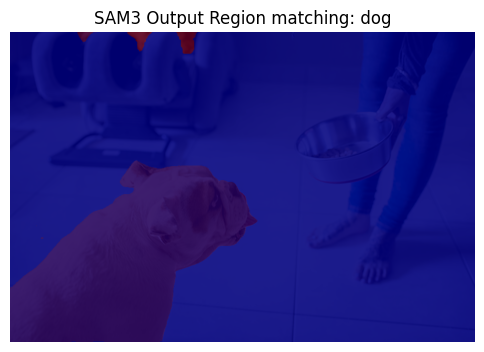

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import os

# 1. Download a sample image if not present (A standard dog picture)
sample_img_path = "sample_test.jpg"
if not os.path.exists(sample_img_path):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg", sample_img_path)

image_pil = Image.open(sample_img_path).convert("RGB")

# 2. Example Text Prompt
text_prompt = "dog"
print(f"Running inference for '{text_prompt}'...")

try:
    # 3. Call the SAM3 Processor on our input mapping
    inputs = processor(images=image_pil, text=text_prompt, return_tensors="pt").to(device)

    # 4. Perform pure inference avoiding gradient backprop (Saves memory)
    with torch.no_grad():
        outputs = model(**inputs)

    # 5. Extract bounding boxes/masks based on confidence threshold
    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=0.3,
        mask_threshold=0.3,
        target_sizes=inputs["original_sizes"].tolist()
    )[0]

    # 6. Safety check & Numpy conversion
    masks = results.get("masks", [])
    if hasattr(masks, "cpu"):
        masks = masks.cpu().numpy()

    # 7. Visualization
    plt.figure(figsize=(6,6))
    plt.imshow(image_pil)
    print(masks)
    for mask in masks:
        plt.imshow(np.squeeze(mask).astype(np.uint8), alpha=0.5, cmap='jet')
    plt.title(f"SAM3 Output Region matching: {text_prompt}")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Inference failed. Check configurations: {e}")


## 4. Student Exploration: Experimenting with Prompts
Now it's your turn! The real power of SAM3 lies in how explicitly defined your requests are.

Instead of broad terms like `"dog"` or `"car"`, experiment with granular sub-components or descriptive variations. For example, test prompts like:
- `"leg"`
- `"background"`
- `"the brown eye"`

**Task:** Write the code below to run SAM3 on the same image using **at least 3 different text prompts** of varying specificity. Display the resulting segmentation masks clearly using `matplotlib`.

Running inference for 'arm'...
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


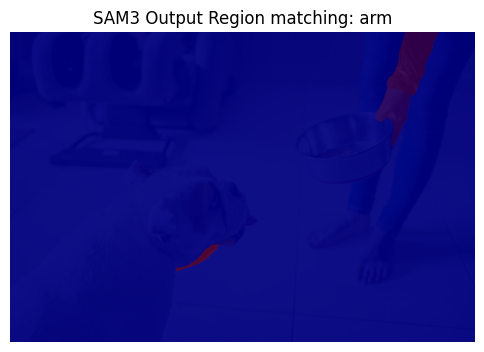

Running inference for 'nose'...
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


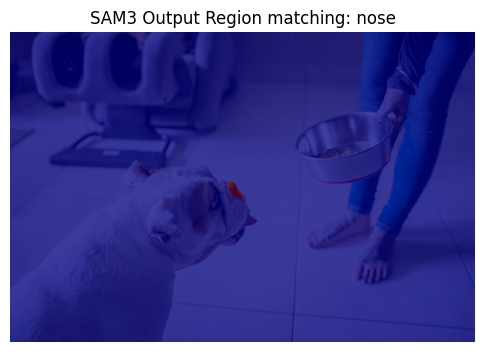

Running inference for 'background'...
[]


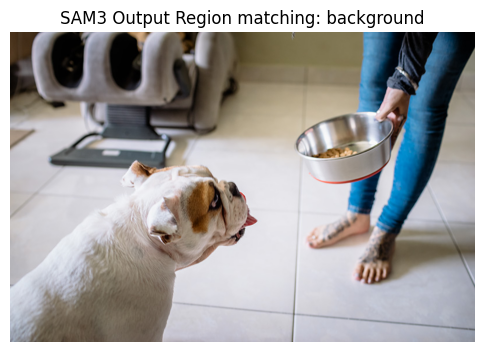

Running inference for 'floor'...
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 0 0 0]]]


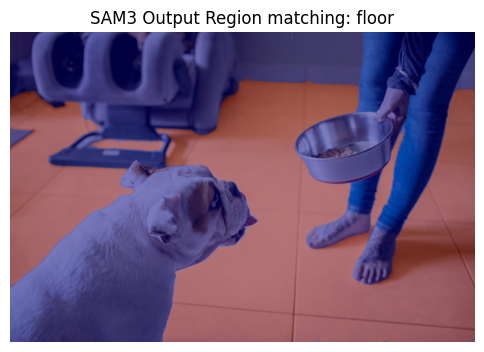

Running inference for 'bowl'...
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


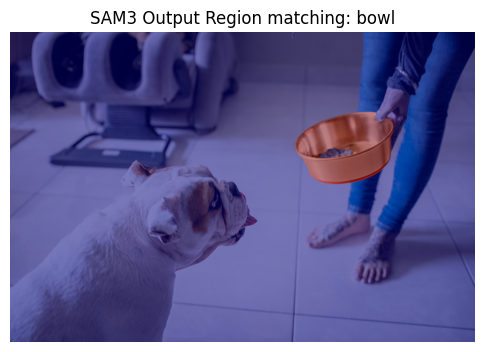

In [ ]:
### --- STUDENT CODE AREA ---
# Try 3 different string prompts below and visualize the generated SAM3 Masks.

prompts_to_try = [
    "arm",
    "nose",
    "background",
    "floor",
    "bowl"
]

# Build out your iteration and visualization code based on the API template in Step 3:
for text_prompt in prompts_to_try:
  print(f"Running inference for '{text_prompt}'...")

  try:
      # 3. Call the SAM3 Processor on our input mapping
      inputs = processor(images=image_pil, text=text_prompt, return_tensors="pt").to(device)

      # 4. Perform pure inference avoiding gradient backprop (Saves memory)
      with torch.no_grad():
          outputs = model(**inputs)

      # 5. Extract bounding boxes/masks based on confidence threshold
      results = processor.post_process_instance_segmentation(
          outputs,
          threshold=0.3,
          mask_threshold=0.3,
          target_sizes=inputs["original_sizes"].tolist()
      )[0]

      # 6. Safety check & Numpy conversion
      masks = results.get("masks", [])
      if hasattr(masks, "cpu"):
          masks = masks.cpu().numpy()

      # 7. Visualization
      plt.figure(figsize=(6,6))
      plt.imshow(image_pil)
      print(masks)
      for mask in masks:
          plt.imshow(np.squeeze(mask).astype(np.uint8), alpha=0.5, cmap='jet')
      plt.title(f"SAM3 Output Region matching: {text_prompt}")
      plt.axis('off')
      plt.show()

  except Exception as e:
      print(f"Inference failed. Check configurations: {e}")



## 5. Results & Explanation
You are required to **interpret the segmentation outputs**, analytically reflect on the model responses, and organize your insights properly rather than just dumping visualizations.

**Questions to answer:**
1. Did increasing prompt specificity accurately constrain the segmentation boundaries? Give examples based on your playground experiments.
2. Based on your tests above, what are the perceived strengths and practical weaknesses of using entirely text-based prompting when trying to isolate objects?

---
*Double click the block below to detail your explanations and neatly format your final submission.*

1. Increasing prompt specificity helped accurately constrain the segmentation boudaries. For example, when inference was ran for the backround, the program was not able to segment anything in the image because it struggled to identify which objects were a part of the background. While when inference was ran for nose, bowl, and floor, the program was able to accurately create a mask for those objects. However, when segmentation was ran for arm, the program mistakenly identified the chin of the dog as an arm (most likely due to the similarity in shape and color).

2. Text-based prompting works best when the text prompt is non ambiguous and specific to a certain object in an image. For example, it works best when describing a certain object in the image like the dog bowl the hand is holding. This allows users to stack multiple constraints until they get their desired outcome (instead of being constrained to one object class).
It works worst the object described is ambiguous. For example, it struggled to identify which objects were a part of the background. It also mistakenly identified the dog's chin as an arm due to the similar shape and color. At the same time, when segmentation was ran for arm, the program was able to identify the human arm but not the dog arm.